<a href="https://colab.research.google.com/github/Sakshi-coder1/workco/blob/main/ML_Day_3%20%26%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("sales.csv")

In [3]:
print(df.head())

   customer_id signup_date country  age  gender loyalty_tier  \
0            1  08-04-2021      BR   48    Male       Bronze   
1            2  28-04-2023      IN   36  Female       Silver   
2            3  18-12-2022      UK   35  Female       Silver   
3            4  26-04-2022      US   45    Male       Silver   
4            5  20-04-2022      IN   53    Male       Silver   

  acquisition_channel  
0            Referral  
1             Organic  
2             Organic  
3         Paid Search  
4             Organic  


In [4]:
encoder=LabelEncoder()
df['loyalty_tier']=encoder.fit_transform(df['loyalty_tier'])

In [5]:
print(df[['loyalty_tier']].head())

   loyalty_tier
0             0
1             3
2             3
3             3
4             3


In [8]:
x=df[['age','loyalty_tier']]

In [9]:
model=KMeans(n_clusters=3,
             random_state=42)
model.fit(x)



KMeans(n_clusters=3, random_state=42)

In [10]:
df['clusters']=model.labels_
print("Clustered customers")

Clustered customers


In [11]:
print(model.cluster_centers_)


[[34.58076133  0.92589974]
 [46.76750959  0.91885965]
 [23.18103549  0.933002  ]]


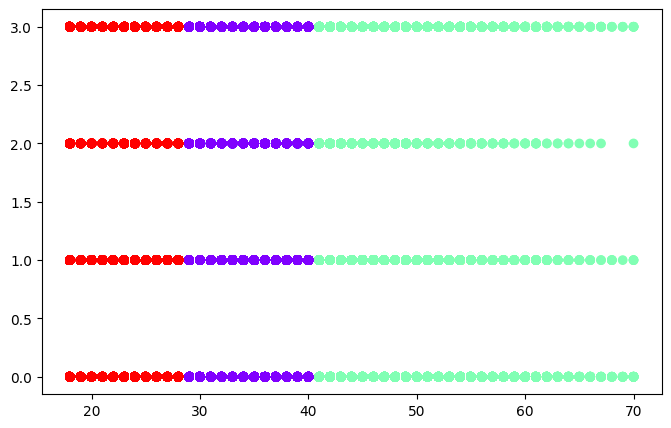

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(
  df['age'],
  df['loyalty_tier'],
  c=df['clusters'],
  cmap='rainbow'
)

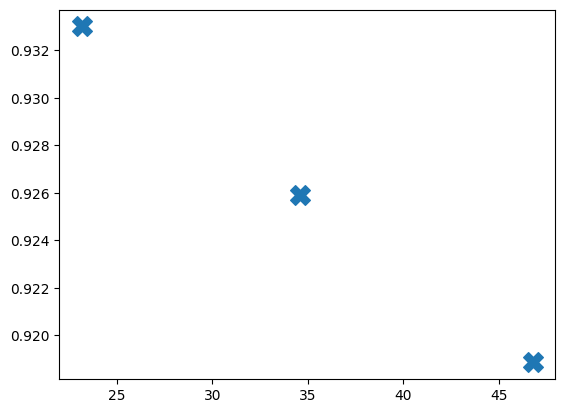

In [15]:
plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    s=200,
    marker='X'
)

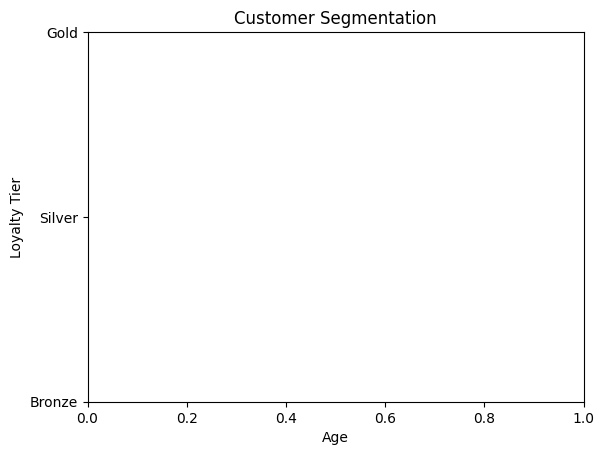

In [18]:
plt.xlabel("Age")
plt.ylabel("Loyalty Tier")
plt.title("Customer Segmentation")
plt.yticks(
    [0,1,2],
    ['Bronze','Silver','Gold']
)
plt.show()